**This script trains one Universal model on all generic turbine data sets by first normalising the DELs against one baseline condition**

In [ ]:
#Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl

from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold

from pygam import LinearGAM, s, te

import joblib

from lifelines.utils import concordance_index

**Creating universal model trained using all GTs**

The single model is trained on the normalised GT data sets (individually normalised)

In [ ]:
base_path = 'add_base_path_here'
figure_path = 'add_figure_path_here'

env_inputs = ['windSpeed', 'iRef', 'shearExp', 'density', 'inFlowAngle']
output = 'damage'
nodes = ['blade_root', 'tower_base']
loads = ['Mx', 'My']
wohlers = [4, 9, 10, 14]
excluded_nodes = {'stationary_hub', 'rotating_hub', 'blade_maxchord', 'tower_top'}

iref_base = 0.14
density_base = 1.15
inflow_base = 0
shear_base = 0.15
windspeed_base =  16 #16m/s found to be optimum

#formula for determining the powered average of damage 
def power_average_damage(damage_values, wohler):
    return (np.mean(damage_values ** wohler)) ** (1/wohler)

**GT DEL normalisation**
DEL normalisation must occur before the universal model can be trained on all GTs

In [ ]:
# ------------------------------------------------------------------ LOAD AND NORMALISE ALL GTs ------------------------------------------------------------------
all_GT_dfs = []

for gt_num in ['3', '4', '5', '10', '11', '12']:
    GT_name = f'GT{gt_num}'
    GT_path = f'{base_path}{GT_name}/'
    GT_df = pd.read_csv(f'{GT_path}{GT_name}_DB_list.csv')
    GT_df = GT_df[~GT_df['node'].isin(excluded_nodes)]
    GT_df['GT'] = GT_name


    # normalise by baseline condition
    baseline_rows = GT_df.loc[
        (GT_df['windSpeed'] == windspeed_base) &
        (GT_df['iRef'] == iref_base) &
        (GT_df['density'] == density_base) &
        (GT_df['shearExp'] == shear_base) &
        (GT_df['inFlowAngle'] == inflow_base),
        ['node', 'load', 'wohler', 'damage']
    ]

    baseline = baseline_rows.groupby(['node', 'load', 'wohler']).apply(
        lambda x: pd.Series({
            'baseline_damage': power_average_damage(x['damage'].values, x.name[2])
        }),
        include_groups=False
    ).reset_index()

    GT_df = GT_df.merge(baseline, on=['node', 'load', 'wohler'], how='left')
    GT_df['damage'] = GT_df['damage'] / GT_df['baseline_damage']

    all_GT_dfs.append(GT_df)
    print(f'{GT_name} loaded and normalised - {len(GT_df)} rows')

#creating one combined dataset of all GTs
combined_df = pd.concat(all_GT_dfs, ignore_index=True)


GT3 loaded and normalised — 63690 rows
GT4 loaded and normalised — 63690 rows
GT5 loaded and normalised — 63690 rows
GT10 loaded and normalised — 63690 rows
GT11 loaded and normalised — 63690 rows
GT12 loaded and normalised — 63690 rows

Combined dataset: 382140 rows
GT
GT3     63690
GT4     63690
GT5     63690
GT10    63690
GT11    63690
GT12    63690
Name: count, dtype: int64


**Training Universal model on all GTs (one GAM based, one PRM based)**

In [ ]:
# ------------------------------------------------------------------ POLYNOMIAL EXPANSION ------------------------------------------------------------------
cv_results_poly = pd.DataFrame()

#looping through all node/load/wohler combinations of the combined GT dataset
for node in nodes:
    for load in loads:
        for wohler in wohlers:
            subset = combined_df[
                (combined_df['node'] == node) &
                (combined_df['load'] == load) &
                (combined_df['wohler'] == wohler)
            ]
            if len(subset) == 0:
                continue

            X = subset[env_inputs]
            y = subset[output]

            #training the poly reg model as before, using 3 degreee polynomial feature expansion and linear regression, standardising the env vars first
            reg_model = Pipeline([
                ('scaler', StandardScaler()),
                ('poly', PolynomialFeatures(degree=3, include_bias=False)),
                ('regression', LinearRegression())
            ])
            #fitting
            reg_model.fit(X, y)

            #scoring
            scores = cross_val_score(reg_model, X, y, cv=5, scoring='r2')
            mse_scores = cross_val_score(reg_model, X, y, cv=5, scoring='neg_mean_squared_error')
            mae_scores = cross_val_score(reg_model, X, y, cv=5, scoring='neg_mean_absolute_error')

            mean_rmse = np.sqrt(-mse_scores.mean())
            mean_mae = -mae_scores.mean()
            rmse_pct = (mean_rmse / y.mean()) * 100
            mae_pct = (mean_mae / y.mean()) * 100

            cv_results_poly.loc[f'{node}_{load}_{wohler}', 'mean_r2'] = round(scores.mean(), 3)
            cv_results_poly.loc[f'{node}_{load}_{wohler}', 'std'] = round(scores.std(), 3)
            cv_results_poly.loc[f'{node}_{load}_{wohler}', 'rmse_pct'] = round(rmse_pct, 1)
            cv_results_poly.loc[f'{node}_{load}_{wohler}', 'mae_pct'] = round(mae_pct, 1)
            cv_results_poly.loc[f'{node}_{load}_{wohler}', 'mean_mae'] = round(mean_mae, 1)

            #saving teh trained universal model
            joblib.dump(reg_model, f'{base_path}UNIVERSAL_Models/poly_UNIVERSAL_model_{node}_{load}_{wohler}_combined_{windspeed_base}.pkl')

#saving the performance metrics
cv_results_poly.to_csv(f'{base_path}poly_UNIVERSAL_cv_results_combined.csv')


#------------------------------------------------------------------ GAM ------------------------------------------------------------------
#the same process above except for tge GAM
cv_results_gam = pd.DataFrame()

#looping though all load/node/wohler subsets
for node in nodes:
    for load in loads:
        for wohler in wohlers:
            subset = combined_df[
                (combined_df['node'] == node) &
                (combined_df['load'] == load) &
                (combined_df['wohler'] == wohler)
            ]
            if len(subset) == 0:
                continue

            X = subset[env_inputs].values
            y = subset[output].values

            #manual cross validation because it is not inherent to pyGam environment
            kf = KFold(n_splits=5, shuffle=True, random_state=42)
            fold_scores = []
            fold_mse = []
            fold_mae = []

            for train_idx, test_idx in kf.split(X):
                X_train, X_test = X[train_idx], X[test_idx]
                y_train, y_test = y[train_idx], y[test_idx]

                #this is dependent on an X order of wind speed, iref, shear exp, density, inflow angle
                gam = LinearGAM(    s(0, n_splines=10) +   # windSpeed - 10 unique values
                                    s(1, n_splines=7) +   # iRef - 7 unique values
                                    s(2, n_splines=4) +   # shearExp - 4 unique values
                                    s(3, n_splines=4) +   # density - 4 unique values
                                    s(4, n_splines=4) +   # inflow angle 3 unique but need 4
                                    te(0,1)+te(0,2)+te(0,4)+te(1,3)+te(0,3))
                gam.fit(X_train, y_train)

                #fold metrics
                y_pred = gam.predict(X_test)
                ss_res = np.sum((y_test - y_pred) ** 2)
                ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
                fold_scores.append(1 - ss_res / ss_tot)
                fold_mse.append(mean_squared_error(y_test, y_pred))
                fold_mae.append(mean_absolute_error(y_test, y_pred))

            #post cv metrics averaged
            mean_rmse = np.sqrt(np.mean(fold_mse))
            mean_mae = np.mean(fold_mae)
            rmse_pct = (mean_rmse / y.mean()) * 100
            mae_pct = (mean_mae / y.mean()) * 100

            #metrics assigned to dataframe
            cv_results_gam.loc[f'{node}_{load}_{wohler}', 'mean_r2'] = round(np.mean(fold_scores), 3)
            cv_results_gam.loc[f'{node}_{load}_{wohler}', 'std'] = round(np.std(fold_scores), 3)
            cv_results_gam.loc[f'{node}_{load}_{wohler}', 'rmse_pct'] = round(rmse_pct, 1)
            cv_results_gam.loc[f'{node}_{load}_{wohler}', 'mae_pct'] = round(mae_pct, 1)
            cv_results_gam.loc[f'{node}_{load}_{wohler}', 'mean_mae'] = round(mean_mae, 1)

            #have to save tge full model
            gam_full = LinearGAM(s(0) + s(1) + s(2) + s(3) + s(4) + te(0,1) + te(0,2) + te(0,4) + te(1,3) + te(0,3))
            gam_full.fit(X, y)

            #saving trained model
            joblib.dump(gam_full, f'{base_path}UNIVERSAL_Models/gam_UNIVERSAL_model_{node}_{load}_{wohler}_combined_{windspeed_base}.pkl')

#saving performance metrics
cv_results_gam.to_csv(f'{base_path}gam_UNIVERSAL_cv_results_combined.csv')

**Running cross comparison with the universal model**
The universal model is tested across all GTs to assess performance - can also use basic model here for cross testing

                     r2  rmse_pct  mae_pct    mae_abs   rmse_abs  c_index
blade_root_Mx_4   0.588       3.6      2.8    55302.1    70332.7    0.840
blade_root_Mx_9   0.272       4.1      3.2    78008.7    98930.7    0.844
blade_root_Mx_10  0.248       4.2      3.3    82254.0   103627.5    0.845
blade_root_Mx_14  0.245       4.6      3.7    97646.6   119247.5    0.850
blade_root_My_4   0.982       5.6      4.2    57782.0    76786.5    0.966
blade_root_My_9   0.971       6.7      5.1   103687.1   135364.2    0.949
blade_root_My_10  0.968       7.0      5.4   113952.1   149084.1    0.946
blade_root_My_14  0.956       8.0      6.2   149168.0   194367.0    0.936
tower_base_My_4   0.968       8.6      6.9   391567.7   488851.1    0.942
tower_base_My_9   0.884      14.3     11.9  1219879.1  1464388.1    0.896
                     r2  rmse_pct  mae_pct    mae_abs   rmse_abs  c_index
blade_root_Mx_4   0.631       4.7      3.6    58467.0    77633.6    0.851
blade_root_Mx_9   0.303       4.9     

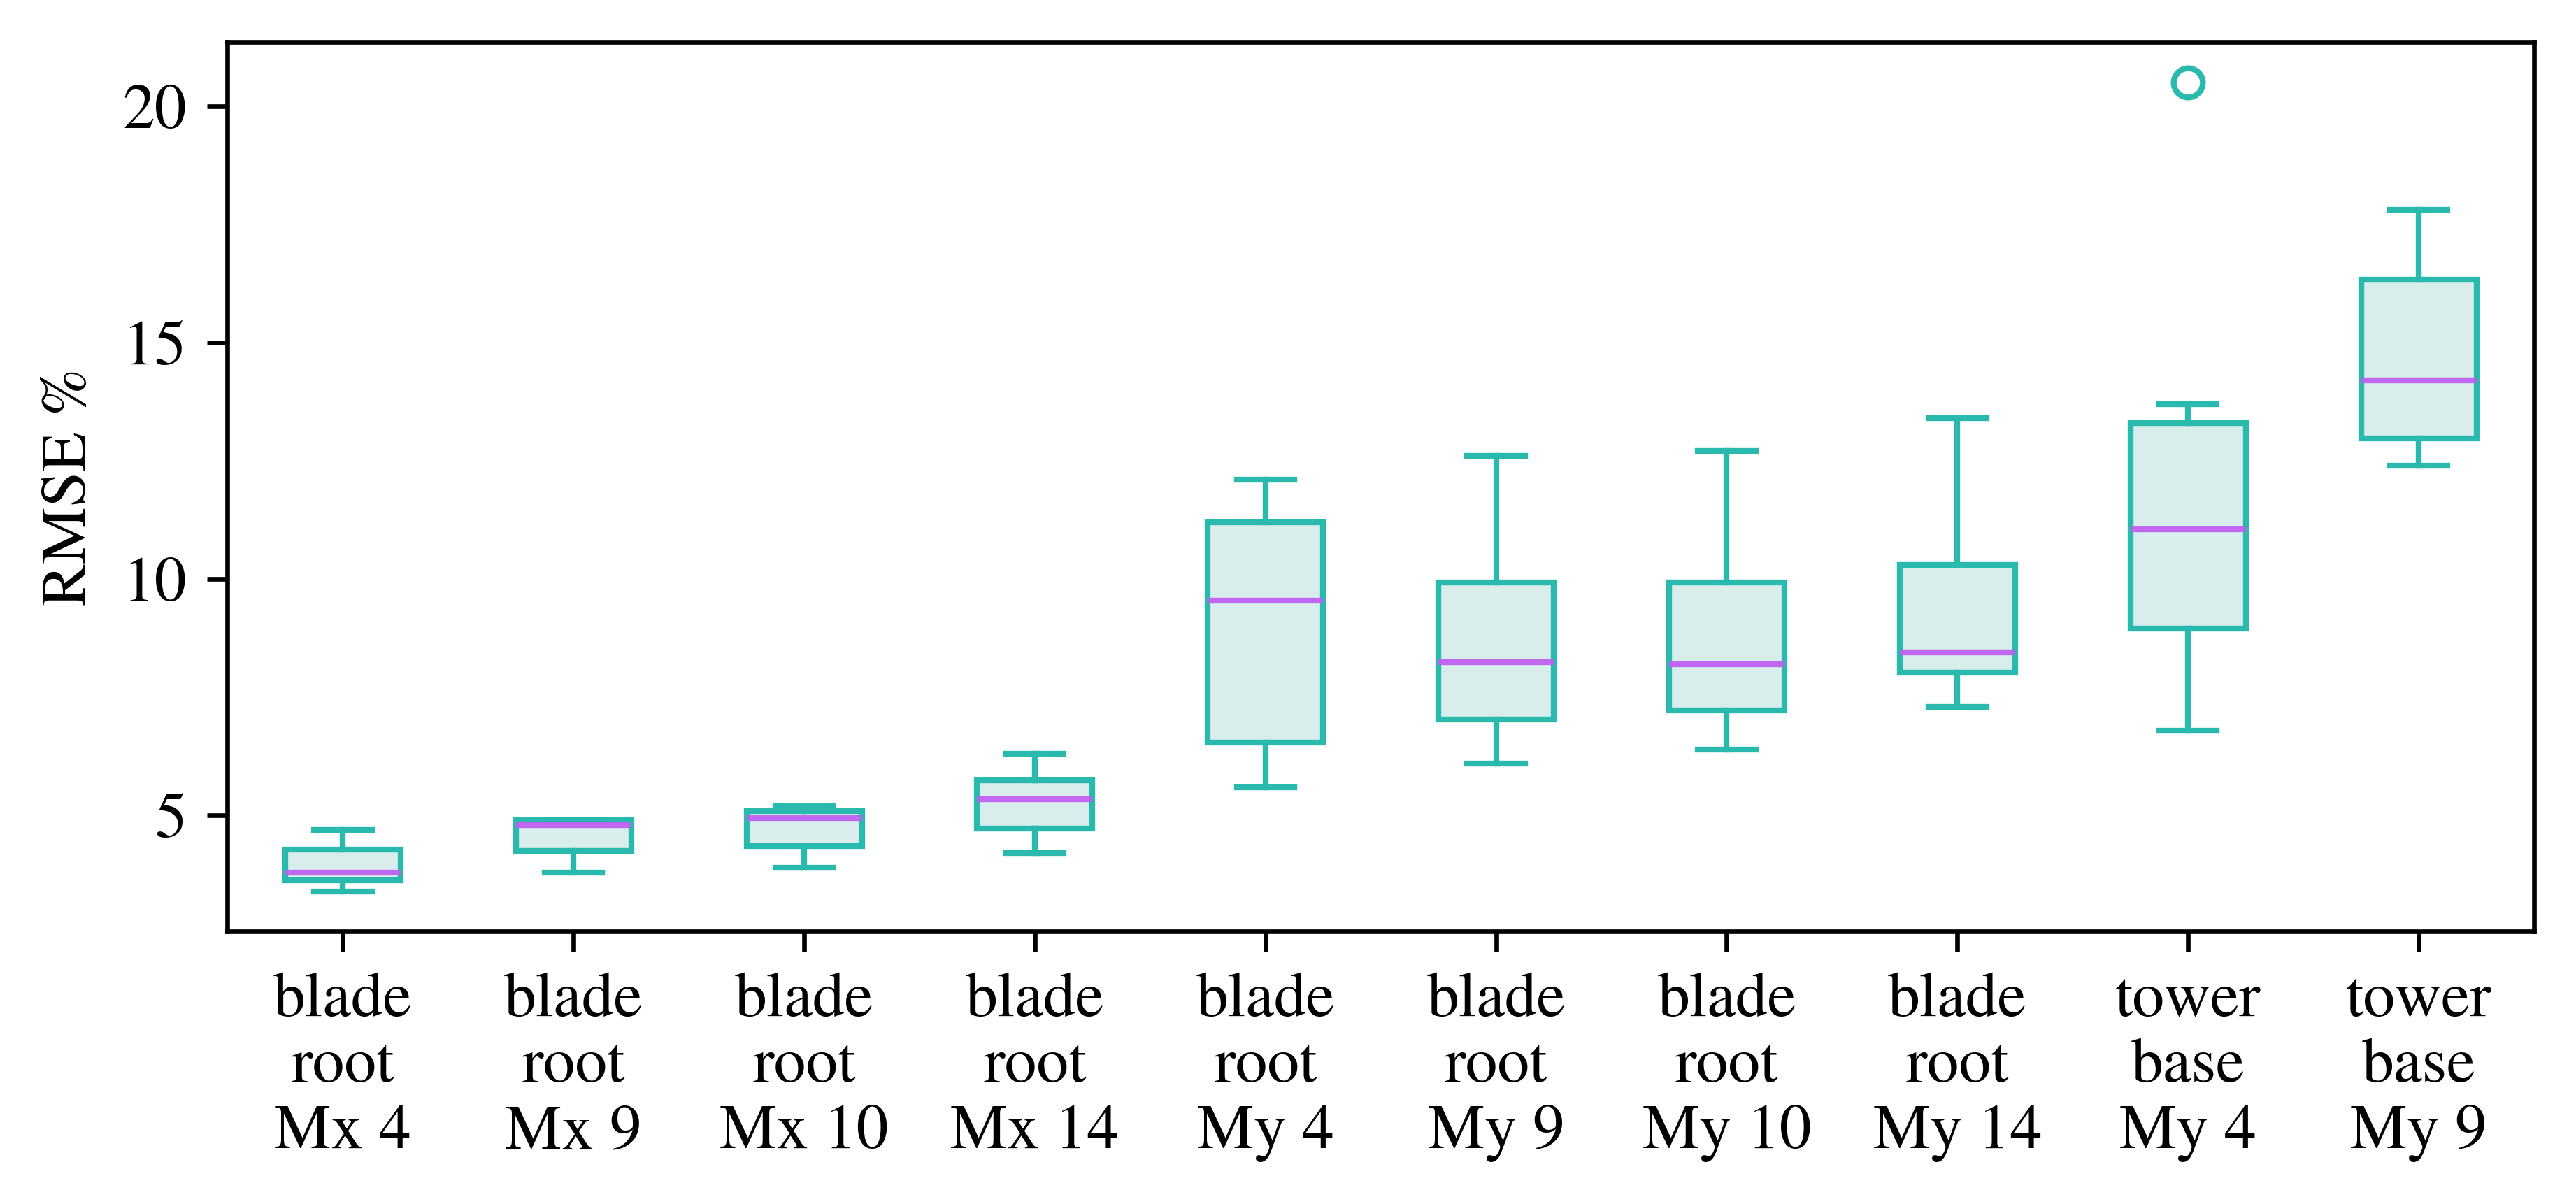

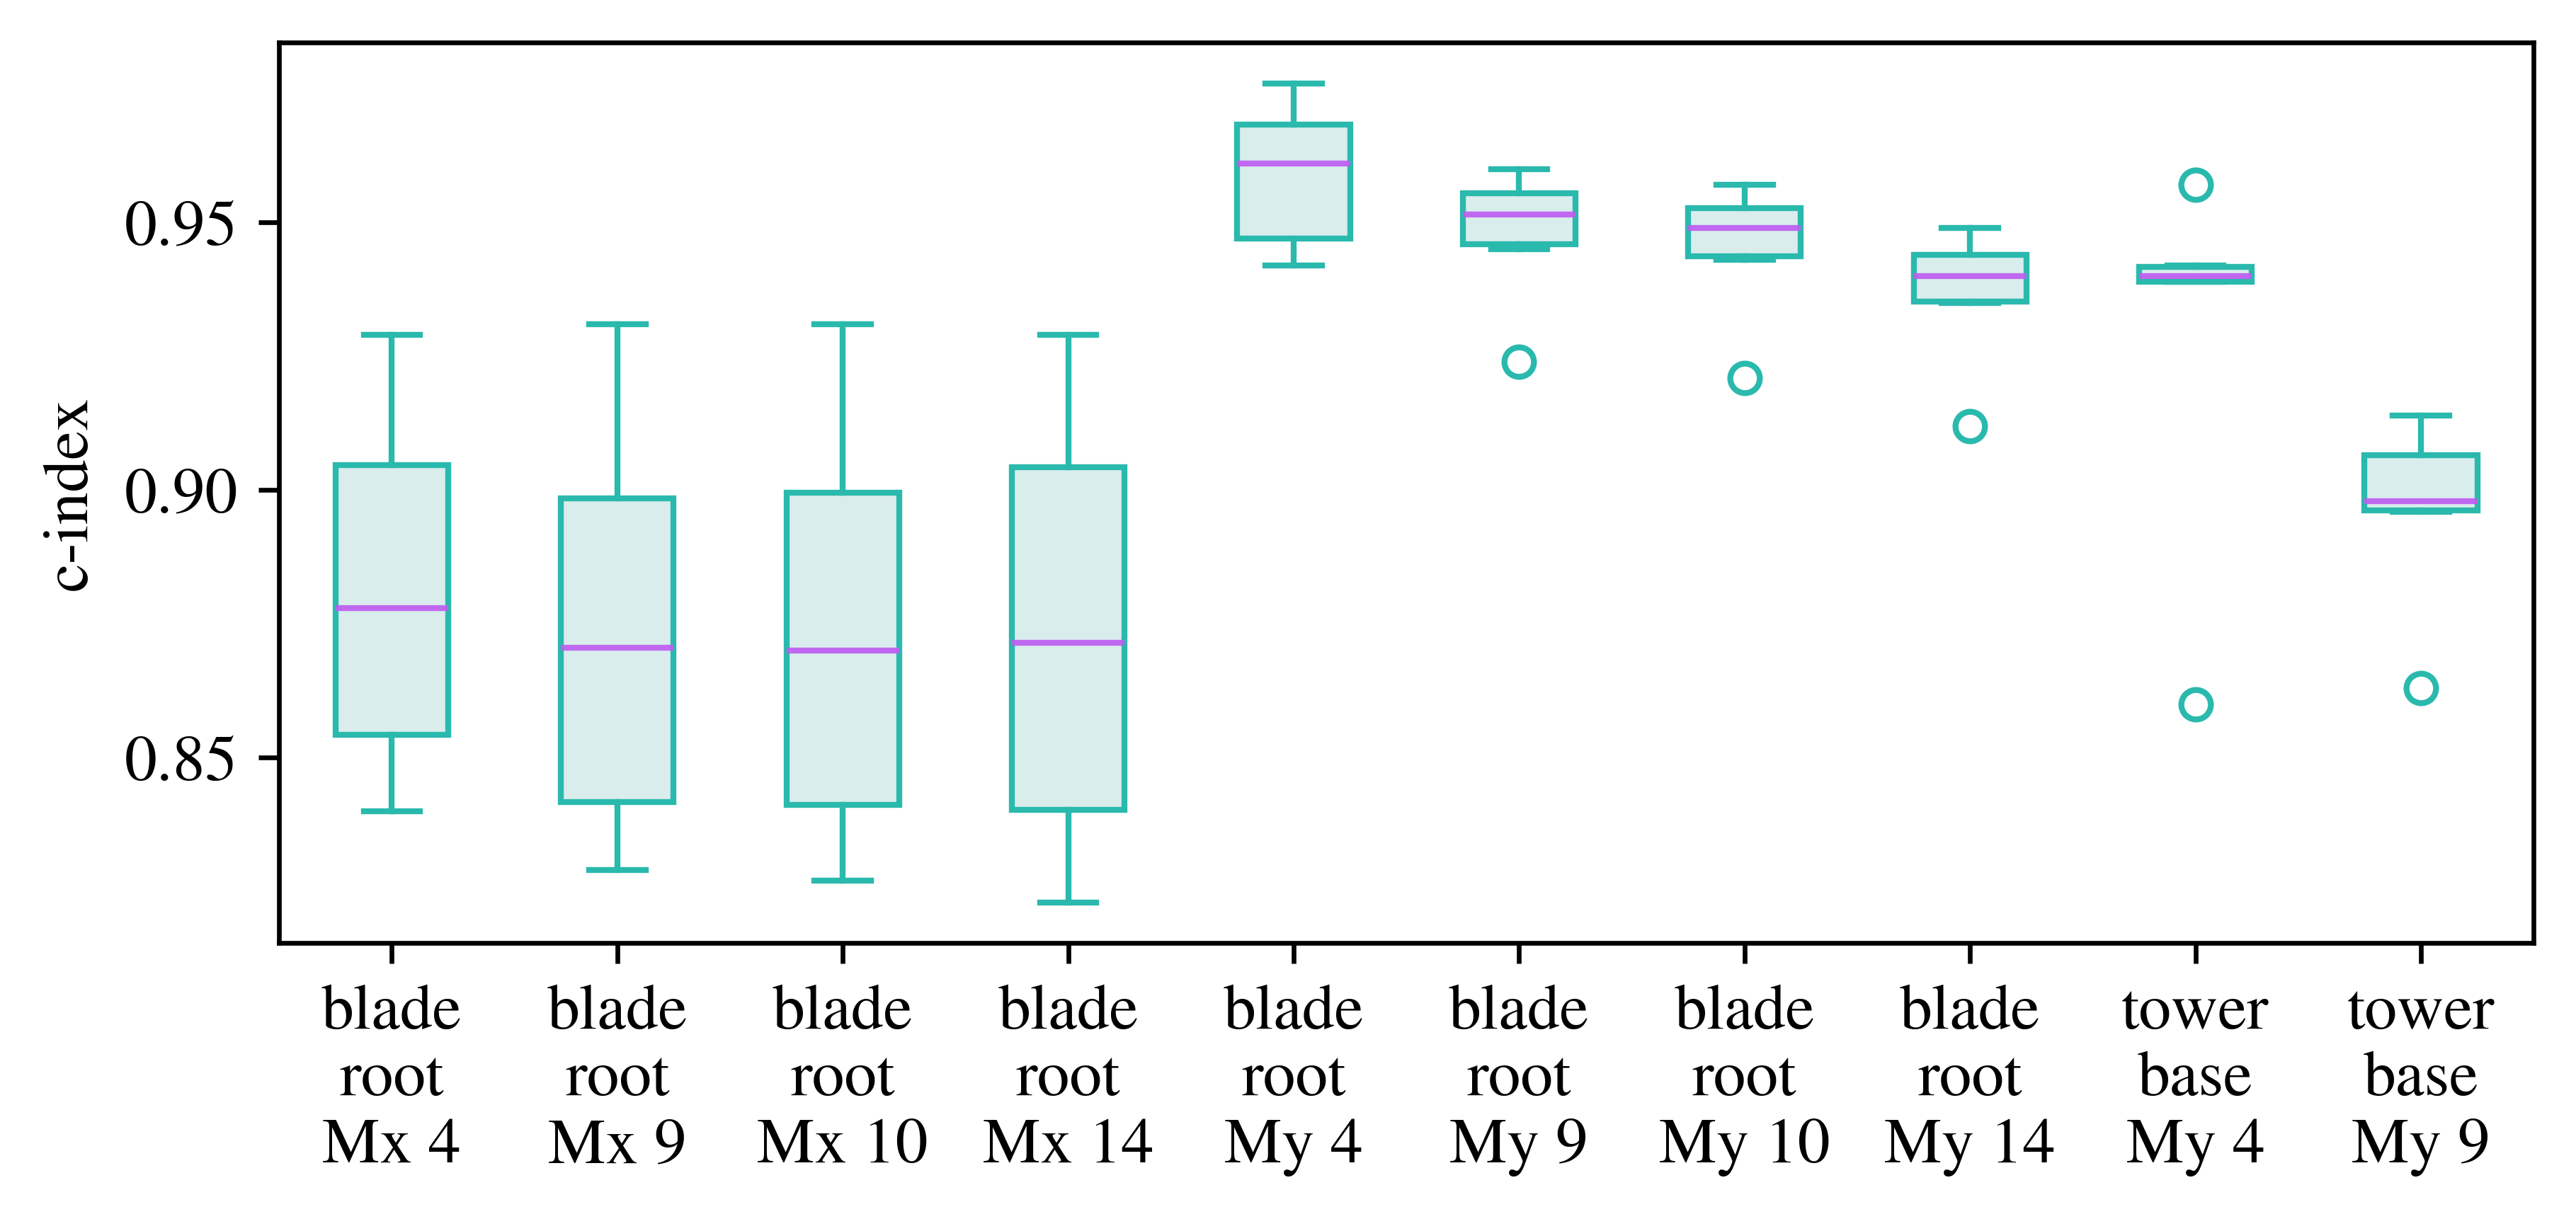

In [ ]:
gts = [3, 4, 5, 10, 11, 12]
GT_comp_results = pd.DataFrame()
GT_comp_results_max = pd.DataFrame()
m = 'poly'  # change to whichever universal model is being tested (poly or gam)
c_indexes = pd.DataFrame()

#power average function
def power_average_damage(damage_values, wohler):
    return (np.mean(damage_values ** wohler)) ** (1 / wohler)

all_errors = pd.DataFrame()

#looping htrough all of the GTs to test
for test_model in gts:

    GT_test_name = f'GT{test_model}'
    GT_test_path = f'{base_path}{GT_test_name}/'
    GT_test_df = pd.read_csv(f'{GT_test_path}{GT_test_name}_DB_list.csv')
    GT_test_df = GT_test_df[~GT_test_df['node'].isin(excluded_nodes)]

    # ------------------------------------------------------ damage normalisation for test df ---------------------------------------------------------------------
    #each GT must be DEL normalised prior to testing
    baseline_rows = GT_test_df.loc[
        (GT_test_df['windSpeed'] == windspeed_base) &
        (GT_test_df['iRef'] == iref_base) &
        (GT_test_df['density'] == density_base) &
        (GT_test_df['shearExp'] == shear_base) &
        (GT_test_df['inFlowAngle'] == inflow_base),
        ['node', 'load', 'wohler', 'damage']
    ]
    #normalisation requires the powered average to find the baseline damage
    baseline = baseline_rows.groupby(['node', 'load', 'wohler']).apply(
        lambda x: pd.Series({
            'baseline_damage': power_average_damage(x['damage'].values, x.name[2])
        }),
        include_groups=False
    ).reset_index()

    #DEL normalised
    GT_test_df = GT_test_df.merge(baseline, on=['node', 'load', 'wohler'], how='left')
    GT_test_df['damage'] = GT_test_df['damage'] / GT_test_df['baseline_damage']

    # ----------------------------------------------------------------------- CROSS TESTING -------------------------------------------------------------------------------------------------------------
    cross_gt_results = pd.DataFrame()
    #looping through all of the node/load/wohler subsets to test
    for node in nodes:
        for load in loads:
            for wohler in wohlers:
                subset_test = GT_test_df[
                    (GT_test_df['node'] == node) &
                    (GT_test_df['load'] == load) &
                    (GT_test_df['wohler'] == wohler)
                ]
                if len(subset_test) == 0:
                    continue

                #defining input and output
                X_test = subset_test[env_inputs]
                y_test = subset_test[output].values

                #loading in the correct uni model for the node/load/wohler subset
                uni_model_path = f'{base_path}UNIVERSAL_Models/{m}_UNIVERSAL_model_{node}_{load}_{wohler}_combined_{windspeed_base}.pkl'
                model = joblib.load(uni_model_path)

                #predicted DEL
                y_pred = model.predict(X_test)

                # calculating performance metrics
                c_idx = concordance_index(y_test, y_pred)
                ss_res = np.sum((y_test - y_pred) ** 2)
                ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)
                r2 = 1 - ss_res / ss_tot
                rmse = np.sqrt(mean_squared_error(y_test, y_pred))
                mae = mean_absolute_error(y_test, y_pred)
                rmse_pct = (rmse / y_test.mean()) * 100
                mae_pct = (mae / y_test.mean()) * 100

                #de-normalising the absolute metrics using the baseline DEL
                subset_baseline = baseline[
                    (baseline['node'] == node) &
                    (baseline['load'] == load) &
                    (baseline['wohler'] == wohler)
                ]['baseline_damage'].values[0]

                y_pred_absolute = y_pred * subset_baseline
                y_test_absolute = y_test * subset_baseline
                mae_absolute = mean_absolute_error(y_test_absolute, y_pred_absolute)
                rmse_absolute = np.sqrt(mean_squared_error(y_test_absolute, y_pred_absolute))  # added, needed below

                #saving the relevent metrics
                cross_gt_results.loc[f'{node}_{load}_{wohler}', 'r2'] = round(r2, 3)
                cross_gt_results.loc[f'{node}_{load}_{wohler}', 'rmse_pct'] = round(rmse_pct, 1)
                cross_gt_results.loc[f'{node}_{load}_{wohler}', 'mae_pct'] = round(mae_pct, 1)
                cross_gt_results.loc[f'{node}_{load}_{wohler}', 'mae_abs'] = round(mae_absolute, 1)
                cross_gt_results.loc[f'{node}_{load}_{wohler}', 'rmse_abs'] = round(rmse_absolute, 1)
                cross_gt_results.loc[f'{node}_{load}_{wohler}', 'c_index'] = round(c_idx, 3)
                c_indexes.loc[f'{node}_{load}_{wohler}', f'GT{test_model}'] = round(c_idx, 3)

    all_errors[GT_test_name] = cross_gt_results['rmse_pct']  # for nodal error analysis boxplot
    cross_gt_results.to_csv(f'{base_path}/cross_gt_results_on_{GT_test_name}_UNIVERSAL_{m}.csv')

    GT_comp_results.loc[f'GT{test_model}', 'mean_rmse_abs'] = cross_gt_results['rmse_abs'].mean()
    GT_comp_results.loc[f'GT{test_model}', 'mean_rmse_pct'] = cross_gt_results['rmse_pct'].mean()
    GT_comp_results.loc[f'GT{test_model}', 'c_index'] = cross_gt_results['c_index'].mean()
    GT_comp_results.loc[f'GT{test_model}', 'r2'] = cross_gt_results['r2'].mean()
    GT_comp_results_max.loc[f'GT{test_model}', 'max_mae_pct'] = cross_gt_results['mae_pct'].max()

mean_rmse_abs = GT_comp_results['mean_rmse_abs'].mean()

GT_comp_results.to_csv(f'{base_path}crossTest_Universal_results/GT_model_cross_test_{m}_UNIVERSAL.csv')
GT_comp_results_max.to_csv(f'{base_path}crossTest_Universal_results/GT_model_cross_test_max{m}_UNIVERSAL.csv')
c_indexes.to_csv(f'{base_path}universal_model_c_index_{m}.csv')

**plotting results**

In [ ]:

mpl.rcParams['font.size'] = 11
mpl.rcParams['axes.titlesize'] = 11
mpl.rcParams['axes.labelsize'] = 11
mpl.rcParams['xtick.labelsize'] = 11
mpl.rcParams['ytick.labelsize'] = 11
mpl.rcParams['legend.fontsize'] = 11
mpl.rcParams['figure.dpi'] = 600

plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['mathtext.fontset'] = 'stix'

GT = [1,2,3,4,5,6]
pfe_color = "#2C706B" 
col = "#2AB9AD"  
face =  "#81C5C04C"  
med =  "#BE5EF1EB" 

# format x axis labels
def format_subset_label(subset_name):
    parts = subset_name.split('_')
    node = 'blade\nroot' if parts[0] == 'blade' else 'tower\nbase'
    load = parts[2]
    wohler = parts[3]
    return f'{node}\n{load} {wohler}'

new_index = {c: format_subset_label(c) for c in all_errors.index}
all_errors = all_errors.rename(index=new_index)

# RMSE boxplot - same formatting
fig, ax = plt.subplots(figsize=(6.27, 3))
bp = all_errors.astype(float).T.boxplot(
    ax=ax, rot=0, grid=False,
    patch_artist=True,
    return_type='dict',
    boxprops=dict(color=col),
    medianprops=dict(color=med),
    whiskerprops=dict(color=col),
    capprops=dict(color=col),
    flierprops=dict(marker='o', markeredgecolor=col, markersize=5)
)
for box in bp['boxes']:
    box.set_facecolor(face)

ax.set_xlabel('')
ax.set_ylabel('RMSE %')
plt.tight_layout()
plt.savefig(f'{figure_path}universal_RMSE_boxplot_{m}.pdf', dpi=600)
plt.show()


# format the c_indexes index the same way as all_errors
c_indexes_formatted = c_indexes.rename(index={c: format_subset_label(c) for c in c_indexes.index})

# C-index boxplot - same formatting as RMSE boxplot
fig, ax = plt.subplots(figsize=(6.27, 3))
bp = c_indexes_formatted.astype(float).T.boxplot(
    ax=ax, rot=0, grid=False,
    patch_artist=True,
    return_type='dict',
    boxprops=dict(color=col),
    medianprops=dict(color=med),
    whiskerprops=dict(color=col),
    capprops=dict(color=col),
    flierprops=dict(marker='o', markeredgecolor=col, markersize=5)
)
for box in bp['boxes']:
    box.set_facecolor(face)

ax.set_xlabel('')
ax.set_ylabel('c-index')
plt.tight_layout()
plt.savefig(f'{figure_path}universal_Cindex_boxplot_{m}.pdf', dpi=600)
plt.show()

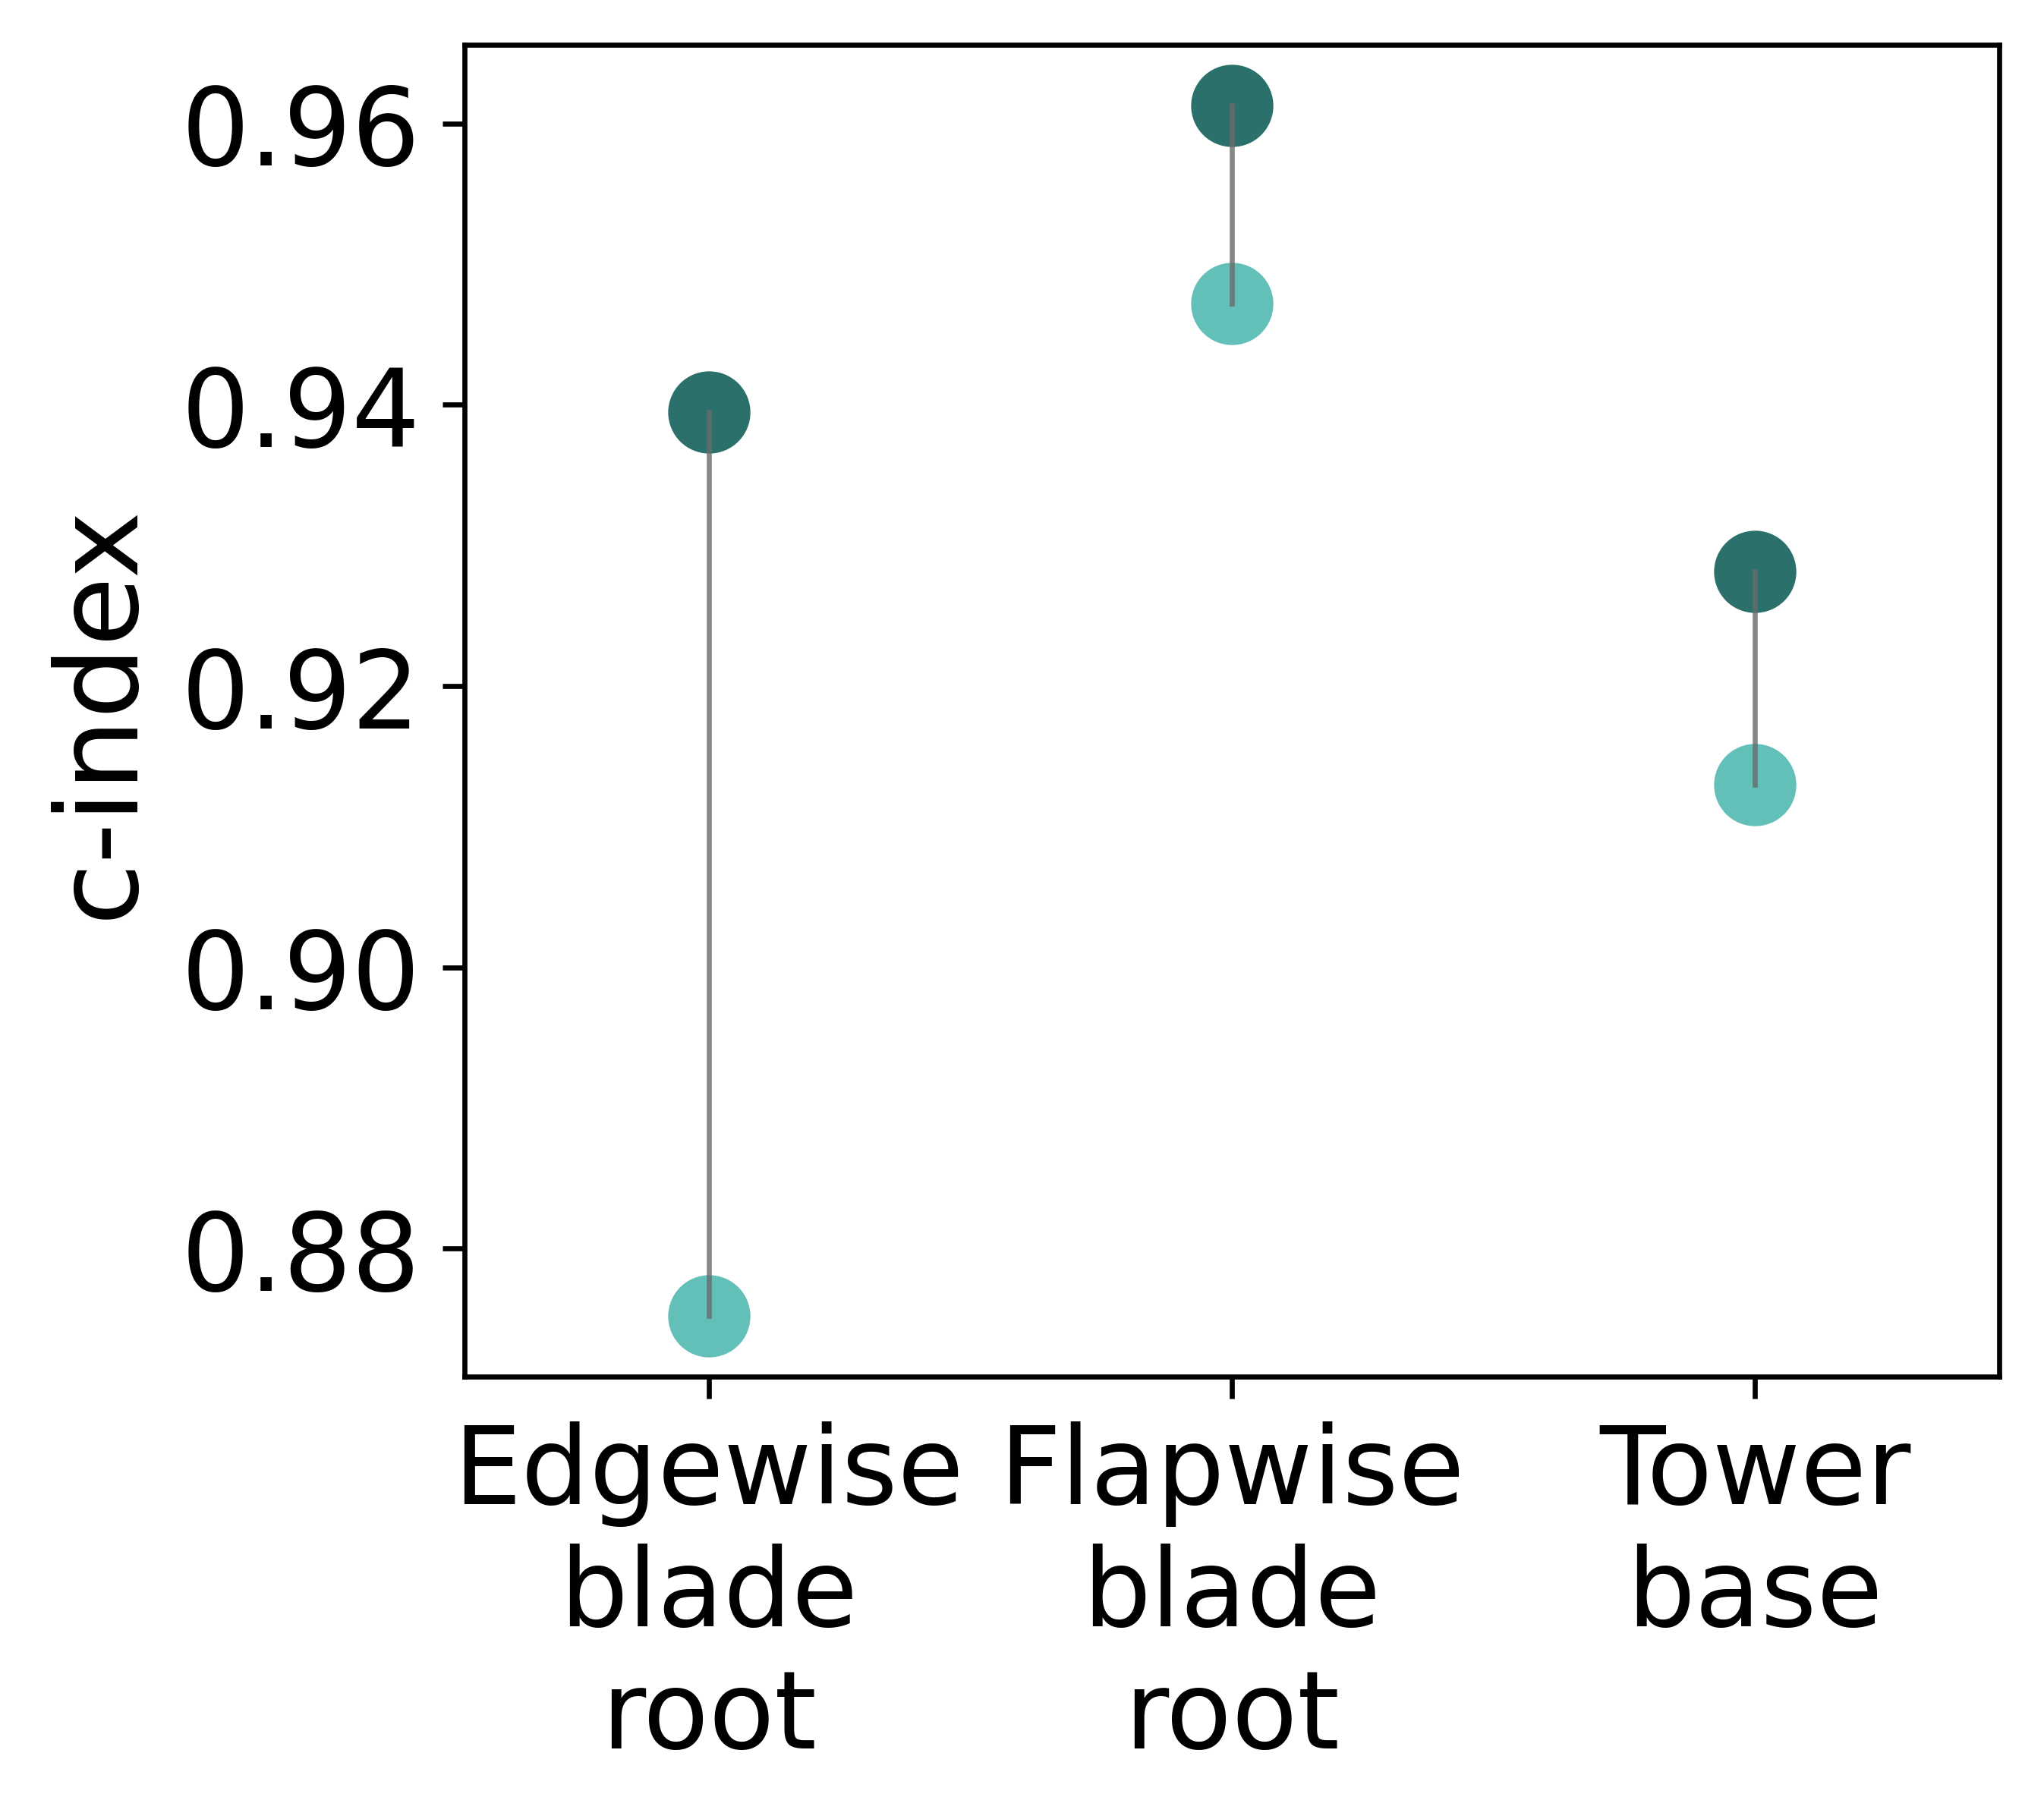

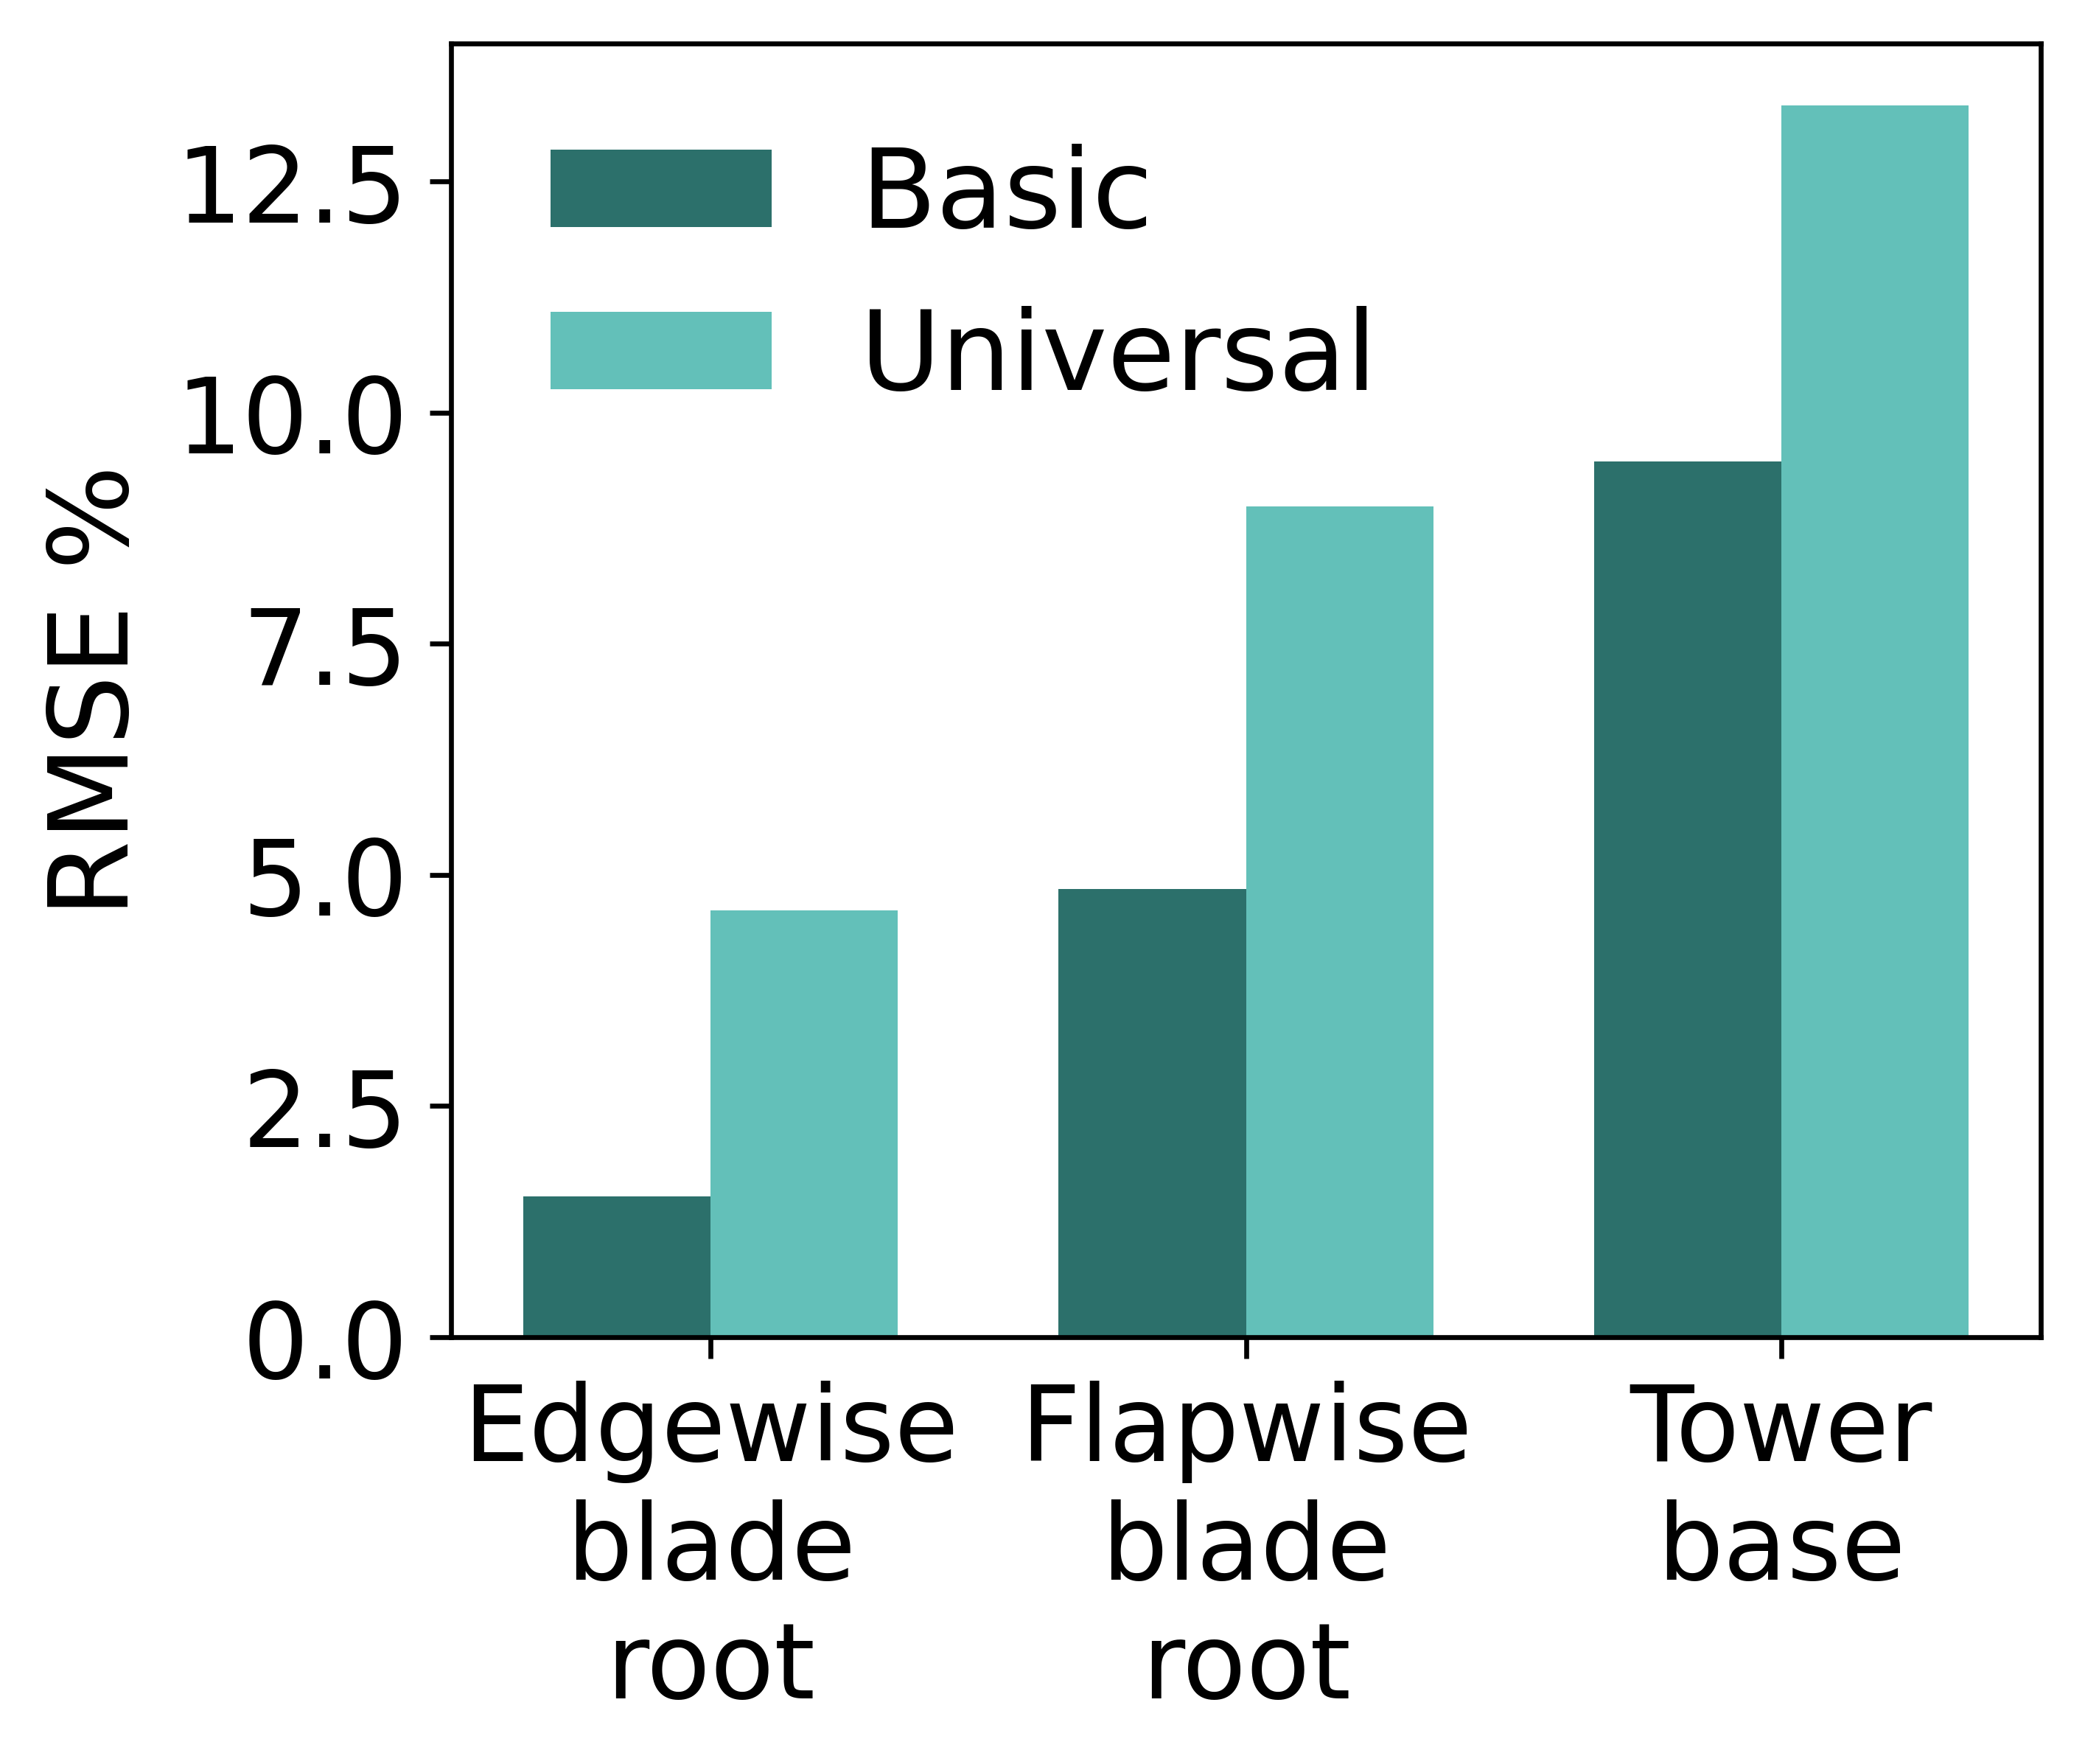

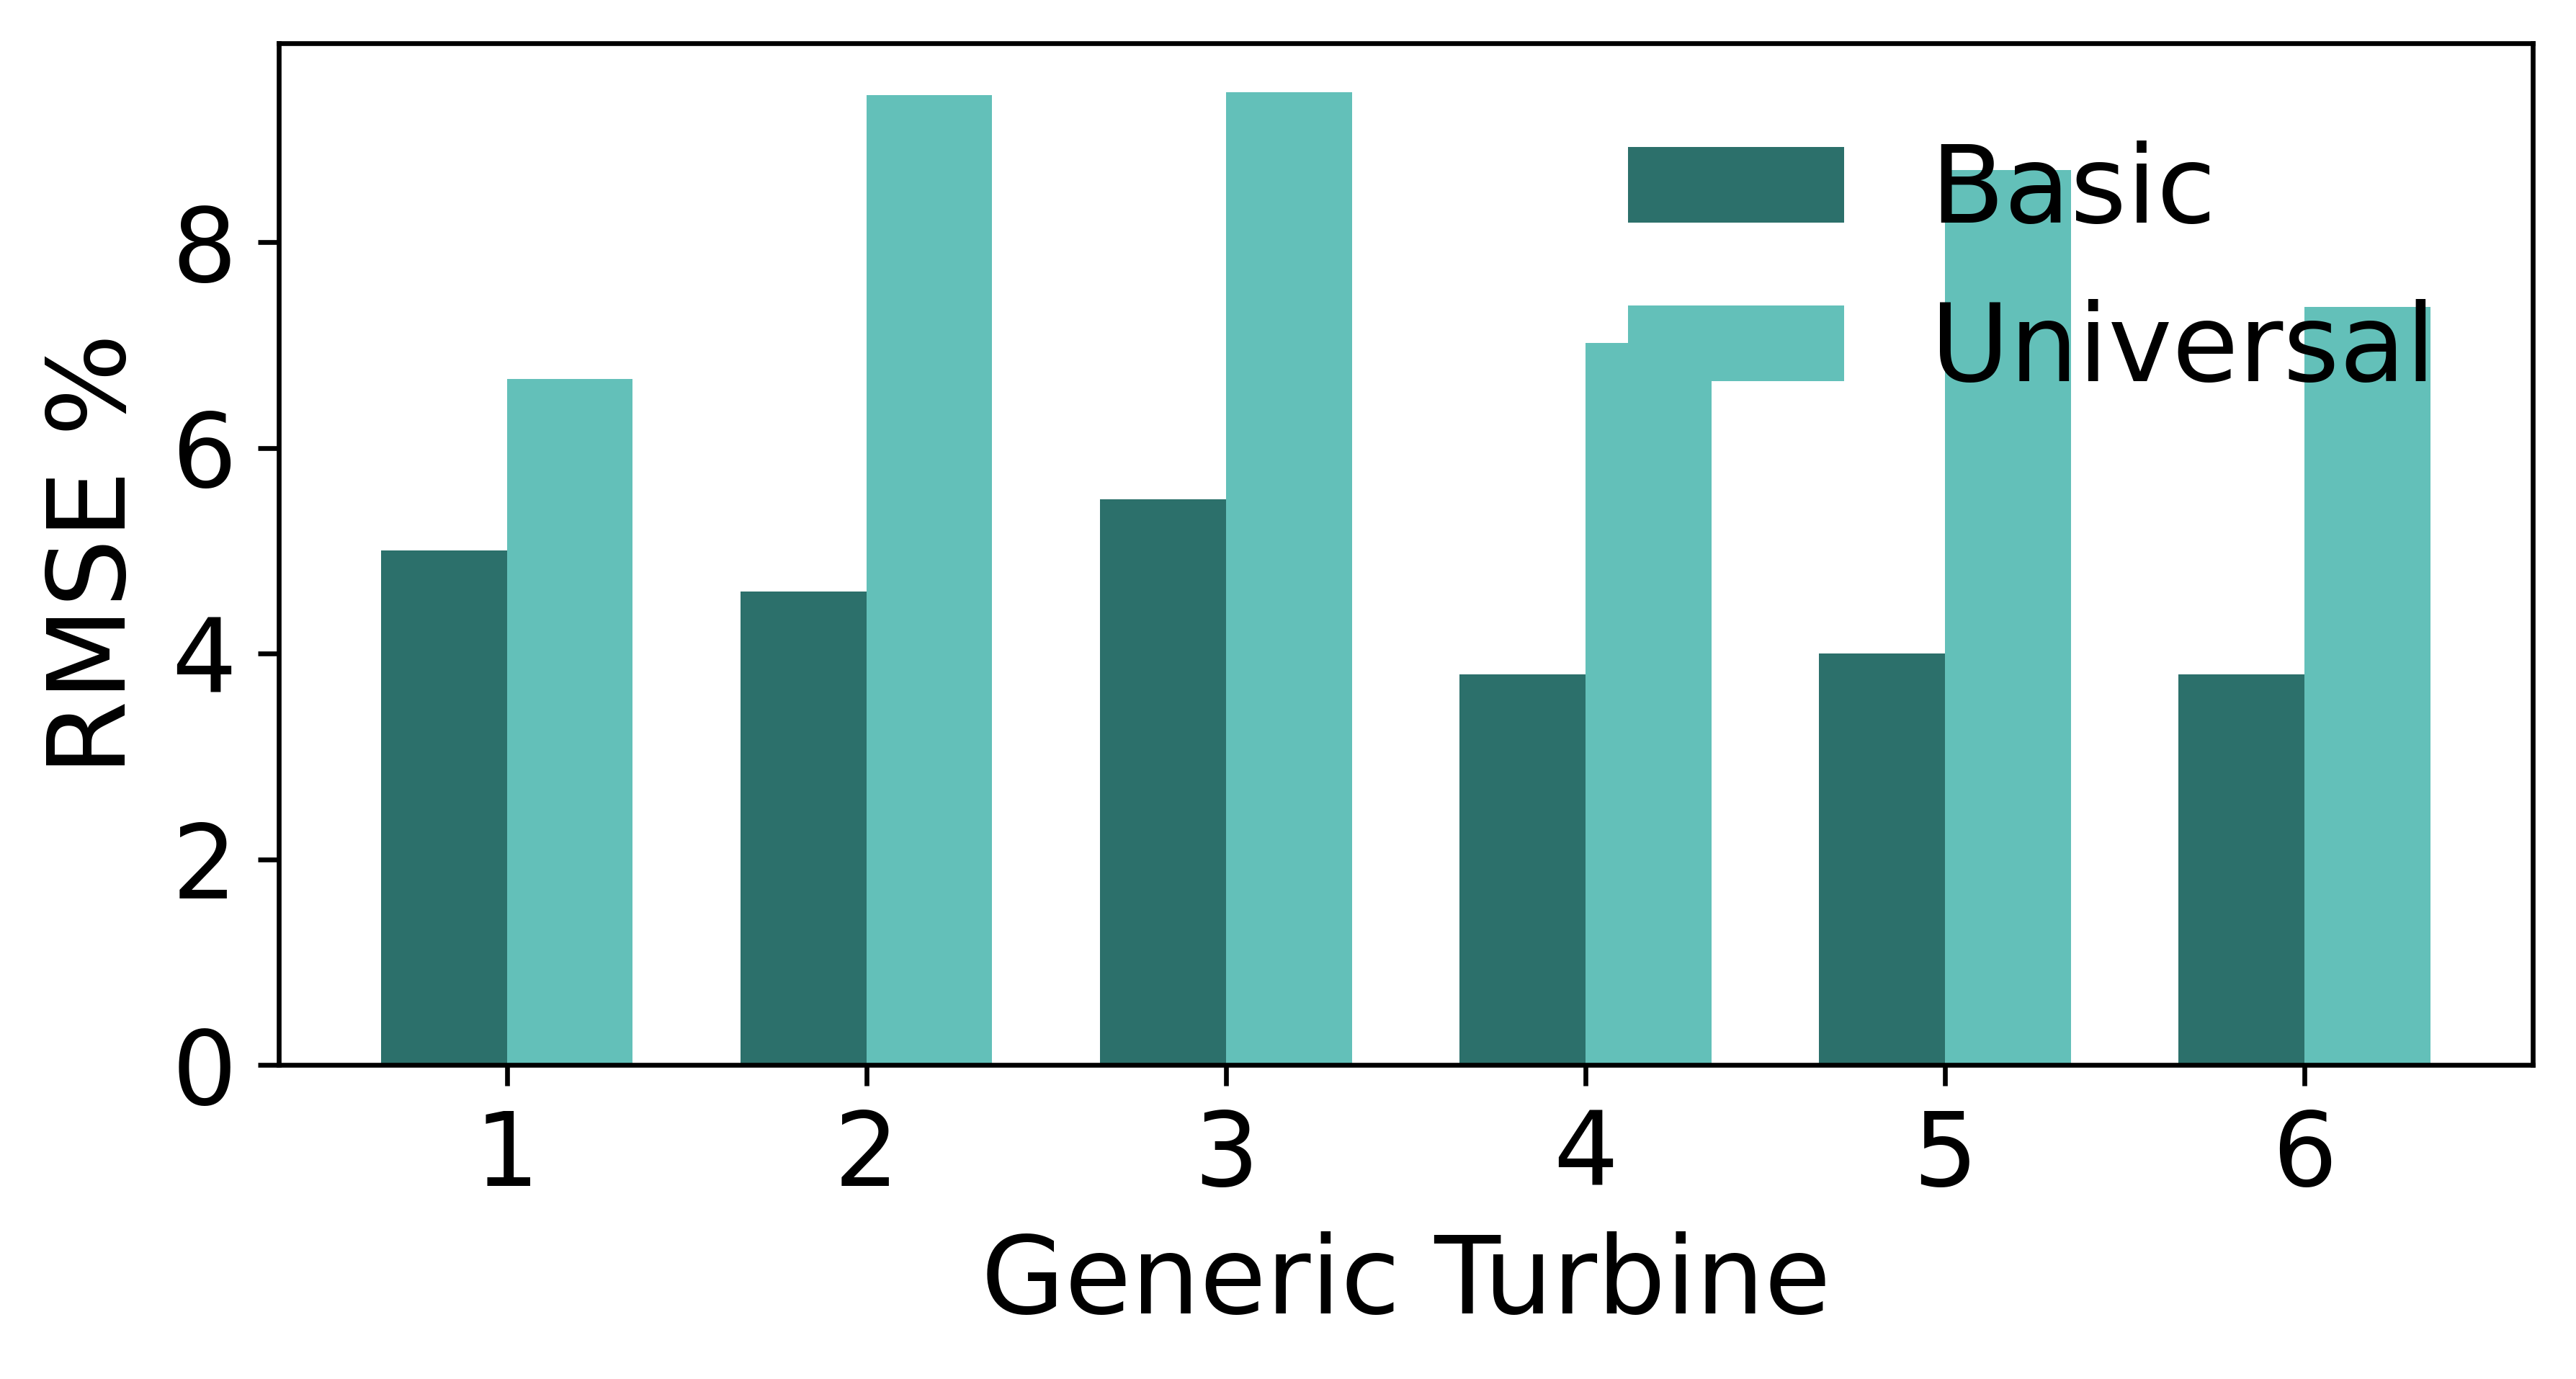

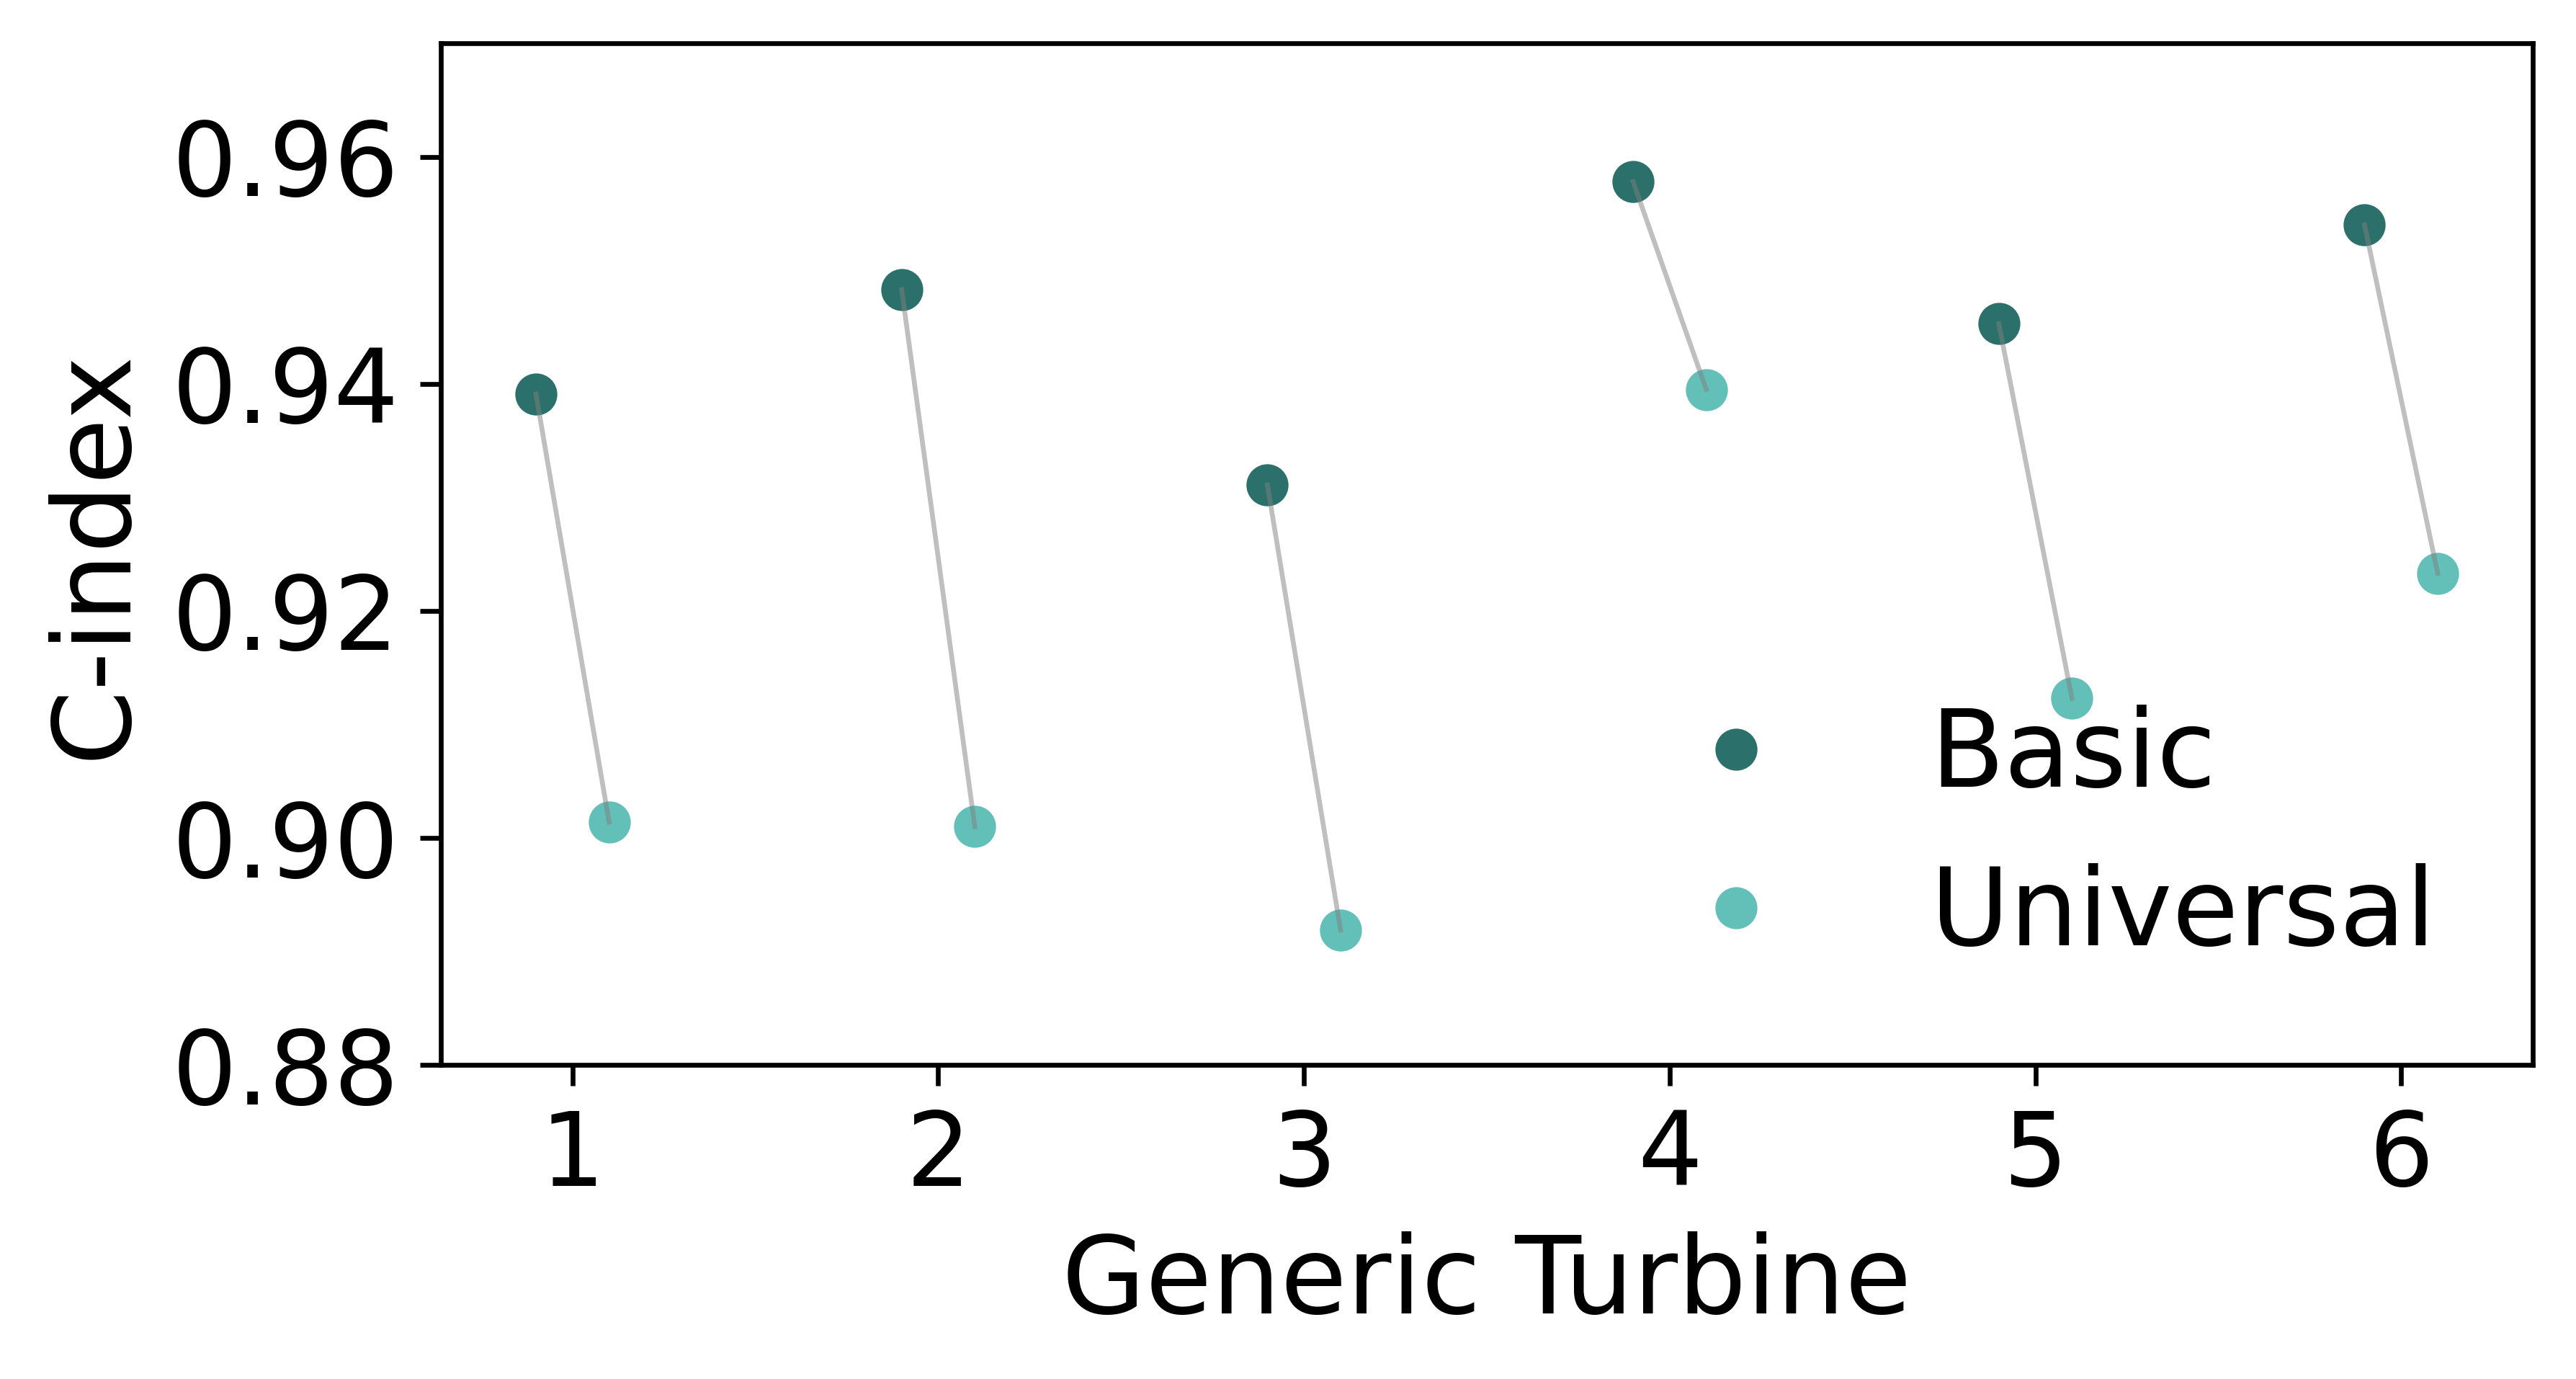

In [ ]:

mpl.rcParams['font.size'] = 17
mpl.rcParams['axes.titlesize'] = 18
mpl.rcParams['axes.labelsize'] = 18
mpl.rcParams['xtick.labelsize'] = 17
mpl.rcParams['ytick.labelsize'] = 17
mpl.rcParams['legend.fontsize'] = 18
mpl.rcParams['figure.dpi'] = 600

# plt.rcParams['font.family'] = 'STIXGeneral'
# plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = "sans-serif"

GT = [1,2,3,4,5,6]
pfe_color = "#2C706B" 
universal_col = "#63C0B9"  

line = "#696B6A"  

universal_rmse = [6.67, 9.43, 9.46, 7.02, 8.7, 7.37]
universal_cdx = [0.9014, 0.901, 0.8919, 0.9395, 0.9123, 0.9233]

pfe_rmse = [5, 4.6, 5.5, 3.8, 4, 3.8]
pfe_cdx = [0.9391, 0.9483, 0.9311, 0.9578, 0.9453, 0.954]

node_error_uni = [4.62, 8.9875,13.325]
node_error_basic = [1.52, 4.84997, 9.475]

node_c_basic = [0.9394583333333333, 0.9612916666666667, 0.9281666666666668]
node_c_uni = [0.8752083333333334, 0.9472083333333333, 0.9129999999999999]


x = np.arange(len(GT))
width = 0.35
l = np.arange(len(node_error_uni))
l_ = l * 0.6

fig, ax = plt.subplots(figsize=(6.27, 3.5))
ax.plot(l_, node_c_basic, 'o', color=pfe_color, label='Basic', markersize=12)
ax.plot(l_, node_c_uni, 'o', color=universal_col, label='Universal', markersize=12)

for i in range(3):
    ax.plot([l_[i], l_[i]], [node_c_basic[i], node_c_uni[i]], 
            color=line, linewidth=0.8, alpha=0.8)
ax.set_xlim(l_.min() - 0.28, l_.max() + 0.28)
ax.set_ylabel('c-index')
ax.set_xticks(l_)
ax.set_xticklabels(['Edgewise\nblade\nroot', 'Flapwise\nblade\nroot', 'Tower\nbase'])
plt.tight_layout()
plt.savefig(f'{figure_path}poster_uni_v_basic_c.png')
plt.show()

# RMSE bar plot per subset
fig, ax = plt.subplots(figsize=(6.27, 3.5))
ax.bar(l - width/2, node_error_basic, width=width, color=pfe_color, label='Basic')
ax.bar(l + width/2, node_error_uni, width=width, color=universal_col, label='Universal')
#ax.set_xlabel('Node')
ax.set_ylabel('RMSE %')
ax.set_xticks(l)
ax.set_xticklabels(['Edgewise\nblade\nroot', 'Flapwise\nblade\nroot', 'Tower\nbase'])
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig(f'{figure_path}poster_uni_v_basic.png')
plt.show()

# RMSE bar plot per GT
fig, ax = plt.subplots(figsize=(6.27, 3.5))
ax.bar(x - width/2, pfe_rmse, width=width, color=pfe_color, label='Basic')
ax.bar(x + width/2, universal_rmse, width=width, color=universal_col, label='Universal')
ax.set_xlabel('Generic Turbine')
ax.set_ylabel('RMSE %')
ax.set_xticks(x)
ax.set_xticklabels(['1','2','3','4','5','6'])
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# C-index dot plot with zoomed axis for each GT
fig, ax = plt.subplots(figsize=(6.27, 3.5))
ax.plot(x - 0.1, pfe_cdx, 'o', color=pfe_color, label='Basic', markersize=6)
ax.plot(x + 0.1, universal_cdx, 'o', color=universal_col, label='Universal', markersize=6)
for i in range(len(GT)):
    ax.plot([i - 0.1, i + 0.1], [pfe_cdx[i], universal_cdx[i]], 
            color='gray', linewidth=0.8, alpha=0.5)
ax.set_xlabel('Generic Turbine')
ax.set_ylabel('C-index')
ax.set_xticks(x)
ax.set_xticklabels(['1','2','3','4','5','6'])
ax.set_ylim(0.88, 0.97)  # zoomed in to show differences
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# mean c-index per subset (averaged across GTs) for both models
universal_cdx_mean = c_indexes_formatted.astype(float).mean(axis=1)

basic_cdx_mean = [0.947, 0.952, 0.953, 0.953, 0.982, 0.965, 0.961, 0.95, 0.955, 0.916]

subsets = c_indexes_formatted.index  # same order for both
x = np.arange(len(subsets))

# C-index dot plot with zoomed axis, over node/load/wohler subsets
fig, ax = plt.subplots(figsize=(6.27, 3.5))
ax.plot(x - 0.1, basic_cdx_mean, 'o', color=pfe_color, label='Basic', markersize=6)
ax.plot(x + 0.1, universal_cdx_mean, 'o', color=universal_col, label='Universal', markersize=6)
for i in range(len(subsets)):
    ax.plot([i - 0.1, i + 0.1], [basic_cdx_mean[i], universal_cdx_mean.iloc[i]],
            color='gray', linewidth=0.8, alpha=0.5)
ax.set_xlabel('')
ax.set_ylabel('C-index')
ax.set_xticks(x)
ax.set_xticklabels(subsets, rotation=0)
ax.set_ylim(0.85, 1.0)
ax.legend(frameon=False, loc = 'upper left')
plt.tight_layout()
plt.show()